# Análisis y Visualización de Clústeres HDBSCAN

## 1. Configuración y Carga de Datos

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

# Asegúrate de que las rutas sean correctas para tu entorno
BASE_OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), "output")
FINAL_CLUSTER_RESULTS_DIR = os.path.join(BASE_OUTPUT_DIR, "Trial_2")

# Archivos de resultados
MODULE_ANALYSIS_SUMMARY_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "hdbscan_module_analysis_summary.csv")
PROTEINS_WITH_GO_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "hdbscan_proteins_with_representative_go.csv")
HDBSCAN_CLUSTER_LABELS_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR,"final_hdbscan_clusters", "hdbscan_cluster_labels_mcs20_ms20_cse0.00_alpha2.0.csv")

# También necesitarás el archivo GO.csv para todos los términos GO
GO_TERMS_PATH = os.path.join(os.path.dirname(os.getcwd()),"input", "GO.csv")
GO_METADATA_PATH = os.path.join(os.path.dirname(os.getcwd()), "input", "metadata_GO.csv")

# Cargar los DataFrames
try:
    df_module_summary = pd.read_csv(MODULE_ANALYSIS_SUMMARY_PATH)
    df_proteins_go = pd.read_csv(PROTEINS_WITH_GO_PATH)
    df_go_terms_all = pd.read_csv(GO_TERMS_PATH, sep='\t') # Asume que GO.csv usa tab como separador
    df_hdbscan_labels = pd.read_csv(HDBSCAN_CLUSTER_LABELS_PATH)
    df_go_metadata = pd.read_csv(GO_METADATA_PATH, sep=',')
    
    print("Archivos cargados exitosamente:")
    print(f" - Resumen de módulos: {len(df_module_summary)} filas")
    print(f" - Proteínas con GO representativo: {len(df_proteins_go)} filas")
    print(f" - Todos los GO terms (para mapeo): {len(df_go_terms_all)} filas")
    print(f" - Etiquetas de clúster HDBSCAN: {len(df_hdbscan_labels)} filas")
    print(f" - Metadata GO: {len(df_go_metadata)} filas")

     # Mapear las proteínas a sus GO terms completos (no solo el representativo del módulo)
    protein_to_all_go_terms = defaultdict(set)
    for _, row in df_go_terms_all.iterrows():
        protein_to_all_go_terms[row['proteina']].add(row['GO_term'])

    # Mapear proteínas a módulos usando df_hdbscan_labels
    protein_module_map = df_hdbscan_labels.set_index('protein_id')['cluster_label'].to_dict()

    # Crear un mapa de módulo a lista de proteínas
    module_to_proteins = defaultdict(list)
    for protein, module_id in protein_module_map.items():
        if module_id != -1: # Excluir ruido para la mayoría de los análisis de clústeres
            module_to_proteins[module_id].append(protein)
    
    # Obtener IDs de clúster válidos y ordenarlos (para el heatmap Jaccard y de términos específicos)
    valid_cluster_ids = sorted(list(module_to_proteins.keys()))
    print(f"Clústeres válidos encontrados: {valid_cluster_ids}")

    # Crear un mapeo de GO_term a Term_Name_Clean para acceso rápido
    go_term_to_name = df_go_metadata.set_index('GO_term')['Term_Name_Clean'].to_dict() # <--- AÑADIDO

except FileNotFoundError as e:
    print(f"Error: Asegúrate de que todos los archivos estén en las rutas correctas. {e}")
    # Puedes salir o manejar el error de otra forma
except Exception as e:
    print(f"Ocurrió un error al cargar los datos: {e}")

Archivos cargados exitosamente:
 - Resumen de módulos: 15 filas
 - Proteínas con GO representativo: 1083 filas
 - Todos los GO terms (para mapeo): 181312 filas
 - Etiquetas de clúster HDBSCAN: 5390 filas
 - Metadata GO: 6928 filas
Clústeres válidos encontrados: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


## 2. Heatmap de Similitud de Clústeres (Basado en GO Terms)

Para crear un heatmap que muestre cuán "parecidos" son los clústeres, podemos calcular una métrica de similitud entre ellos.
Una forma robusta es calcular la **similitud Jaccard** o la **similitud de superposición** de los conjuntos de términos GO asociados a las proteínas de cada clúster.

**Estrategia:**
1. Para cada clúster, recopilar *todos* los términos GO de las proteínas que lo componen.
2. Calcular la similitud (e.g., Jaccard Index) entre el conjunto de GO terms de cada par de clústeres.
   * **Jaccard Index (A, B) = |A ∩ B| / |A ∪ B|**
   * Donde A y B son los conjuntos de GO terms de dos clústeres.
 3. Visualizar la matriz de similitud como un heatmap.

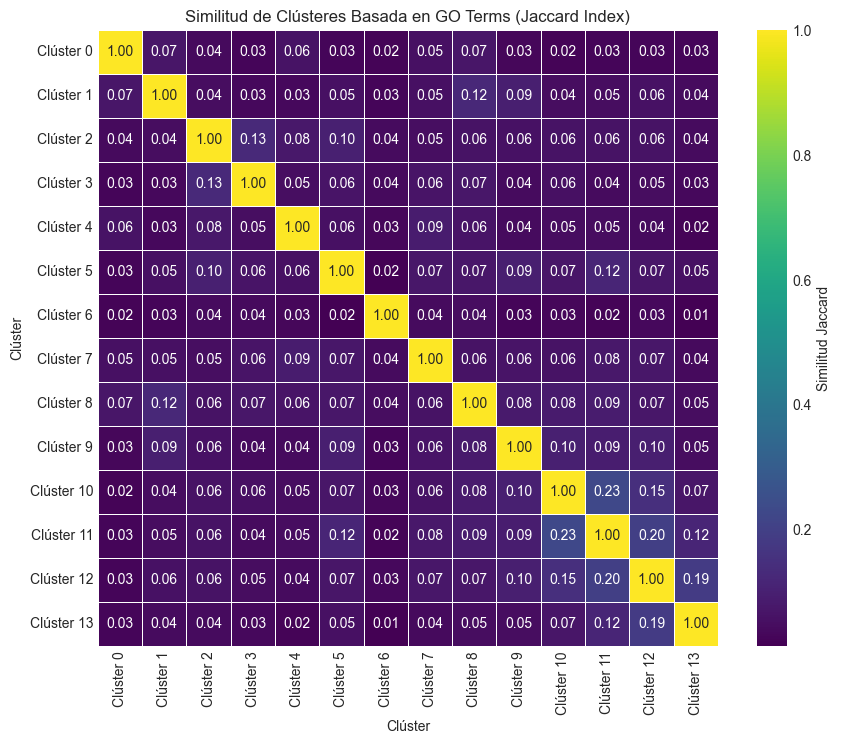

In [87]:

# Paso 1: Recopilar todos los GO terms por clúster (excluyendo ruido)
cluster_go_sets = {}
for module_id, proteins_in_module in module_to_proteins.items():
    current_go_set = set()
    for protein_id in proteins_in_module:
        current_go_set.update(protein_to_all_go_terms[protein_id])
    cluster_go_sets[module_id] = current_go_set

# Obtener IDs de clúster válidos y ordenarlos
valid_cluster_ids = sorted(list(cluster_go_sets.keys()))
num_clusters = len(valid_cluster_ids)

# Paso 2: Calcular la matriz de similitud Jaccard
jaccard_similarity_matrix = np.zeros((num_clusters, num_clusters))

for i, cluster_a_id in enumerate(valid_cluster_ids):
    for j, cluster_b_id in enumerate(valid_cluster_ids):
        set_a = cluster_go_sets[cluster_a_id]
        set_b = cluster_go_sets[cluster_b_id]

        if not set_a or not set_b: # Evitar división por cero si un clúster no tiene GO terms
            jaccard_similarity_matrix[i, j] = 0.0
            continue
        
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        
        if union == 0:
            jaccard_similarity_matrix[i, j] = 0.0
        else:
            jaccard_similarity_matrix[i, j] = intersection / union

# Crear un DataFrame para el heatmap
df_jaccard = pd.DataFrame(jaccard_similarity_matrix, 
                          index=[f'Clúster {cid}' for cid in valid_cluster_ids], 
                          columns=[f'Clúster {cid}' for cid in valid_cluster_ids])

# Paso 3: Visualizar el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_jaccard, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Similitud Jaccard'})
plt.title('Similitud de Clústeres Basada en GO Terms (Jaccard Index)')
plt.xlabel('Clúster')
plt.ylabel('Clúster')
plt.show()

**Interpretación del Heatmap de Similitud GO:**

* **Diagonal:** Siempre será 1.00, ya que un clúster es idéntico a sí mismo.
* **Valores altos (cercanos a 1):** Indican que los dos clústeres comparten una alta proporción de sus términos GO asociados, sugiriendo funciones biológicas similares o relacionadas.
* **Valores bajos (cercanos a 0):** Indican que los clústeres tienen pocos o ningún término GO en común, sugiriendo funciones biológicas muy distintas.
Esto te ayudará a identificar si algunos de tus 7 clústeres, aunque distintos en el espacio de embeddings, tienen solapamiento funcional.

### 2.1. Distribución de Target_Group por Clúster (Gráfico de Barras Apiladas) (SIN RUIDO)

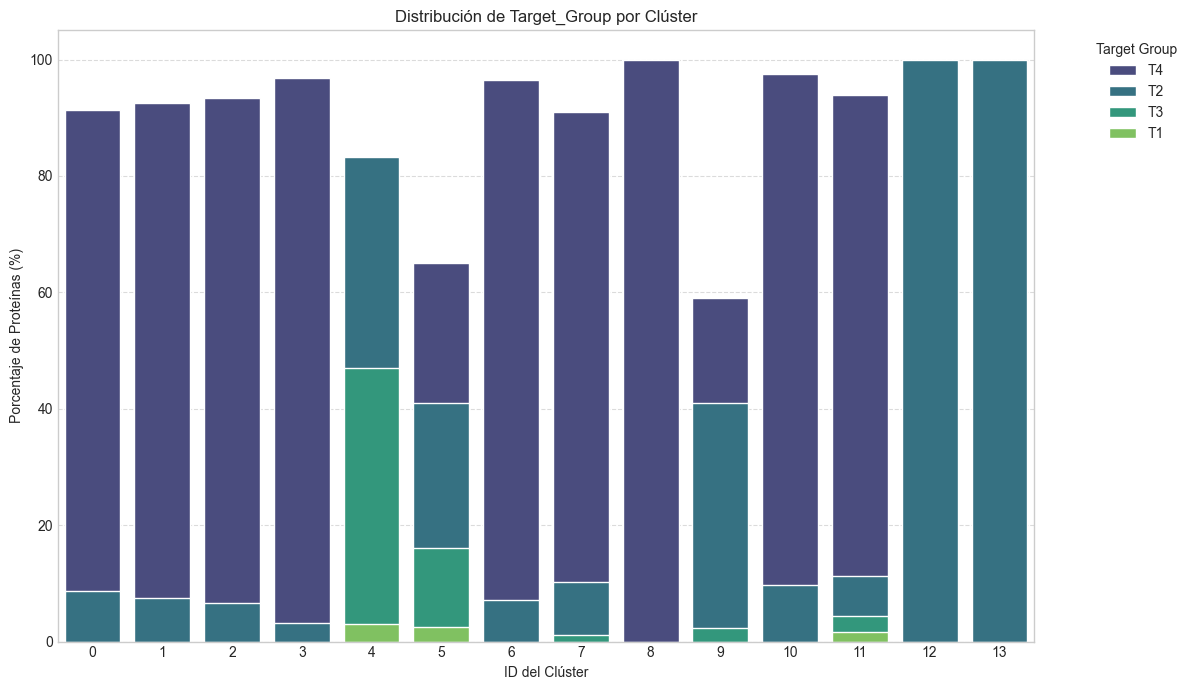

In [88]:
# Esto te permitirá comparar visualmente las proporciones de T1, T2, T3, T4 en cada clúster.

# Preparar los datos para el gráfico de barras apiladas de Target_Group
# Necesitamos parsear la columna 'target_group_distribution'
parsed_target_groups = []
for _, row in df_module_summary.iterrows():
    module_id = row['module_id']
    if module_id == -1: # Puedes incluir el ruido si quieres, o excluirlo
        continue
    
    # Evaluar la cadena a un diccionario
    tg_dist_str = row['target_group_distribution']
    # Eliminar las comillas dobles si las hay antes de evaluar
    tg_dist_str = tg_dist_str.replace("'", "\"")
    try:
        tg_dict = eval(tg_dist_str) # Cuidado con eval, solo si confías en el origen de los datos
    except:
        print(f"Error al parsear target_group_distribution para módulo {module_id}: {tg_dist_str}")
        continue

    total_percentage = 0.0
    for tg, percentage_str in tg_dict.items():
        percentage = float(percentage_str.replace('%', ''))
        parsed_target_groups.append({'module_id': module_id, 'Target_Group': tg, 'Percentage': percentage})
        total_percentage += percentage
    
    # Handle cases where total is not 100% due to floating point or missing groups
    # You might want to normalize if sum is not 100
    # if abs(total_percentage - 100.0) > 0.01 and total_percentage > 0:
    #     print(f"Warning: Module {module_id} target group percentages sum to {total_percentage:.2f}%")

df_tg_distribution = pd.DataFrame(parsed_target_groups)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_tg_distribution, x='module_id', y='Percentage', hue='Target_Group', palette='viridis', dodge=False)
plt.title('Distribución de Target_Group por Clúster')
plt.xlabel('ID del Clúster')
plt.ylabel('Porcentaje de Proteínas (%)')
plt.legend(title='Target Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.2. Distribución de Proteínas DEG por Clúster (Gráfico de Barras Apiladas)


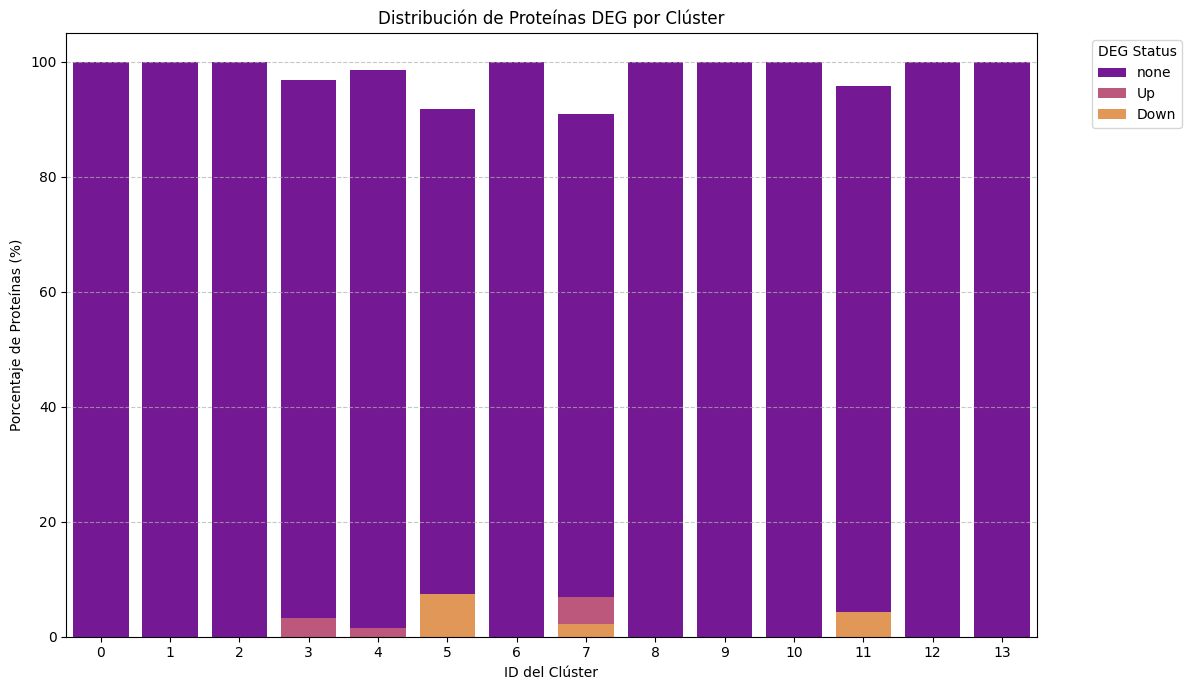

In [5]:
# Similar al anterior, pero para las proteínas diferencialmente expresadas.

# Preparar los datos para el gráfico de barras apiladas de DEG
# Necesitamos parsear la columna 'deg_distribution'
parsed_degs = []
for _, row in df_module_summary.iterrows():
    module_id = row['module_id']
    if module_id == -1: # Puedes incluir el ruido si quieres, o excluirlo
        continue

    deg_dist_str = row['deg_distribution']
    deg_dist_str = deg_dist_str.replace("'", "\"")
    try:
        deg_dict = eval(deg_dist_str)
    except:
        print(f"Error al parsear deg_distribution para módulo {module_id}: {deg_dist_str}")
        continue
    
    total_percentage = 0.0
    for status, percentage_str in deg_dict.items():
        percentage = float(percentage_str.replace('%', ''))
        parsed_degs.append({'module_id': module_id, 'DEG_Status': status, 'Percentage': percentage})
        total_percentage += percentage

df_deg_distribution = pd.DataFrame(parsed_degs)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_deg_distribution, x='module_id', y='Percentage', hue='DEG_Status', palette='plasma', dodge=False)
plt.title('Distribución de Proteínas DEG por Clúster')
plt.xlabel('ID del Clúster')
plt.ylabel('Porcentaje de Proteínas (%)')
plt.legend(title='DEG Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 ### 3.3. Tamaño de los Clústeres y su GO Representativo (Tabla Resumen)

In [6]:
# Una tabla simple para ver rápidamente el tamaño y la función principal de cada clúster.

# Filtrar solo los clústeres válidos (excluir ruido)
df_summary_display = df_module_summary[df_module_summary['module_id'] != -1].copy()

# Opcional: Simplificar la columna 'proteins' si es muy larga para la vista
df_summary_display['proteins_sample'] = df_summary_display['proteins'].apply(lambda x: ', '.join(x.split(', ')[:5]) + '...' if len(x.split(', ')) > 5 else x)

# Seleccionar y reordenar columnas para una mejor visualización
summary_cols = ['module_id', 'module_size', 'representative_go', 'representative_go_p_value', 
                'deg_distribution', 'target_group_distribution', 'proteins_sample']

display(df_summary_display[summary_cols])


,module_id,module_size,representative_go,representative_go_p_value,deg_distribution,target_group_distribution,proteins_sample
1,0,23,GO:0043202 (Lysosomal Lumen),1.639042e-25,{'none': '100.00%'},"{'T4': '91.30%', 'T2': '8.70%'}","MAN2B1, GLB1, ASAH1, NAGLU, IDUA..."
2,1,40,GO:1903027 (Regulation Of Opsonization),2.287545e-23,{'none': '100.00%'},"{'T4': '92.50%', 'T2': '7.50%'}","SERPING1, CPX-6211, CPX-6215, APCS, SERPINF2..."
3,2,61,GO:0007601 (Visual Perception),1.937404e-18,{'none': '100.00%'},"{'T4': '93.44%', 'T2': '6.56%'}","ROM1, RD3, KCNV2, CRX, ABCA4..."
4,3,31,GO:0007605 (Sensory Perception Of Sound),1.356550e-24,"{'none': '96.77%', 'Up': '3.23%'}","{'T4': '96.77%', 'T2': '3.23%'}","ILDR1, CLIC5, PCDH15, GRXCR2, GRXCR1..."
5,4,66,GO:0019585 (Glucuronate Metabolic Process),2.040040e-28,"{'none': '98.48%', 'Up': '1.52%'}","{'T4': '16.67%', 'T2': '83.33%', 'T3': '46.97%...","AKR1D1, CYP2C9, CYP2C19, CYP1A2, CYP2A6..."
6,5,366,GO:0098916 (Anterograde Trans-Synaptic Signaling),9.480695e-124,"{'none': '91.80%', 'Down': '7.38%', 'Up': '0.8...","{'T2': '40.98%', 'T3': '16.12%', 'T4': '65.03%...","DRD4, GNB3, GNB4, SLC6A4, GNB5..."
7,6,28,GO:0004812 (aminoacyl-tRNA Ligase Activity),1.072460e-41,{'none': '100.00%'},"{'T4': '96.43%', 'T2': '7.14%'}","TSFM, EARS2, SARS1, AARS1, NARS1..."
8,7,88,GO:0005759 (Mitochondrial Matrix),1.862956e-37,"{'none': '90.91%', 'Up': '6.82%', 'Down': '2.2...","{'T4': '90.91%', 'T2': '10.23%', 'T3': '1.14%'}","GALM, CPX-6236, PKLR, GBE1, PGD..."
9,8,53,GO:0062023 (Collagen-Containing Extracellular ...,1.789903e-54,{'none': '100.00%'},{'T4': '100.00%'},"CPX-466, BMP1, CPX-1772, CPX-1776, CPX-1778..."
10,9,44,GO:0038196 (Type III Interferon-Mediated Signa...,5.148172e-46,{'none': '100.00%'},"{'T4': '59.09%', 'T2': '40.91%', 'T3': '2.27%'}","IRF1, TLR9, CD79A, TLR3, ICOS..."


### 3.4. (Avanzado) Similitud de GO a nivel de términos específicos

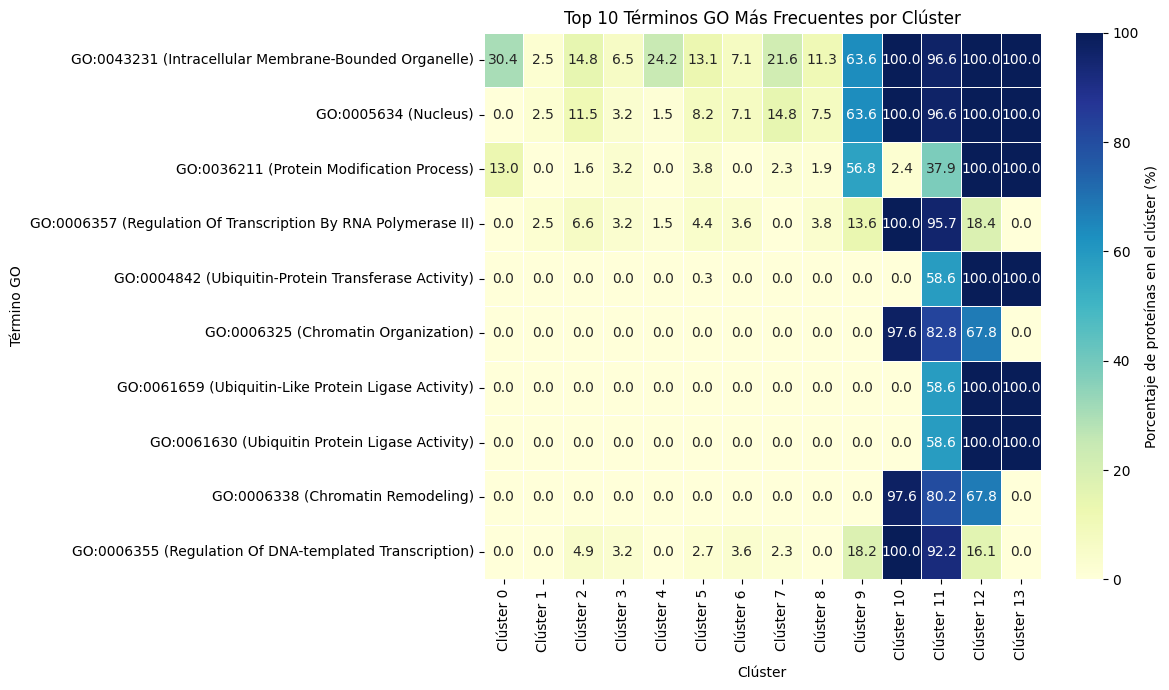

In [7]:

# Para una comprensión más profunda de la superposición funcional, podemos identificar los top N términos GO más 
# frecuentes en cada clúster (excluyendo el ruido) y luego visualizar sus frecuencias a través de todos los clústeres en un heatmap.
# Esto nos permite ver qué funciones son prominentes en cada grupo y cuáles son compartidas.


from collections import Counter

# Definir el número de top GO terms a considerar por clúster
TOP_N_GO_TERMS = 10 

# Recopilar todos los GO terms (con sus nombres) para cada clúster
cluster_go_term_counts = {}
for module_id in valid_cluster_ids: # valid_cluster_ids ya excluye el ruido
    proteins_in_module = module_to_proteins.get(module_id, [])
    
    all_go_terms_for_module = []
    for protein_id in proteins_in_module:
        all_go_terms_for_module.extend(list(protein_to_all_go_terms[protein_id]))
    
    go_counts = Counter(all_go_terms_for_module)
    cluster_go_term_counts[module_id] = go_counts

# Identificar los TOP N GO terms globales (los más frecuentes en el conjunto de todos los clústeres)
global_top_go_terms = Counter()
for module_id, counts in cluster_go_term_counts.items():
    global_top_go_terms.update(counts)

# Seleccionar los TOP N términos más frecuentes en el universo de clústeres no ruidosos
common_go_terms_for_heatmap = [go_term for go_term, _ in global_top_go_terms.most_common(TOP_N_GO_TERMS)]

# Preparar la matriz de frecuencia para el heatmap
# Filas: GO Terms, Columnas: Clústeres
heatmap_data = pd.DataFrame(index=[f"{term} ({go_term_to_name.get(term, 'N/A')})" # <--- CAMBIO AQUÍ
                                   for term in common_go_terms_for_heatmap],
                            columns=[f'Clúster {cid}' for cid in valid_cluster_ids])

for go_term_full_name in heatmap_data.index:
    # Extraer el GO_term puro si incluye el nombre limpio
    go_term_id = go_term_full_name.split(' ')[0] 
    
    for cluster_col in heatmap_data.columns:
        cluster_id = int(cluster_col.split(' ')[1])
        
        # Obtener el número total de proteínas en el módulo para normalizar
        module_size = len(module_to_proteins.get(cluster_id, []))
        
        if module_size > 0:
            # Frecuencia del GO term en este módulo
            count = cluster_go_term_counts[cluster_id].get(go_term_id, 0)
            heatmap_data.loc[go_term_full_name, cluster_col] = (count / module_size) * 100 # Porcentaje
        else:
            heatmap_data.loc[go_term_full_name, cluster_col] = 0

heatmap_data = heatmap_data.astype(float) # Asegurar que los datos son numéricos

# Paso 3: Visualizar el heatmap
plt.figure(figsize=(12, TOP_N_GO_TERMS * 0.7)) # Ajustar tamaño vertical según N
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=.5, cbar_kws={'label': 'Porcentaje de proteínas en el clúster (%)'})
plt.title(f'Top {TOP_N_GO_TERMS} Términos GO Más Frecuentes por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Término GO')
plt.tight_layout()
plt.show()

**Interpretación de este Heatmap de Frecuencia de GO:**

* **Filas:** Representan los GO terms más comunes en tus clústeres.
* **Columnas:** Representan cada uno de tus clústeres.
* **Celdas:** Muestran el **porcentaje de proteínas dentro de ese clúster** que están anotadas con ese término GO específico.
* **Valores altos (colores oscuros):** Indican que ese término GO es muy prevalente en ese clúster particular.
* **Patrones:** Observa si hay términos GO que son muy altos en uno o dos clústeres pero bajos en otros, lo que indica especialización funcional. También busca términos que sean moderadamente altos en muchos clústeres, sugiriendo funciones más generales o compartidas.


## 3. Se genera archivo con métricas topológicas

In [2]:
import pandas as pd
import os
import networkx as nx
import numpy as np

# --- Configuración de directorios y rutas de archivos ---
# Asegúrate de que estas rutas sean correctas para tu entorno
BASE_OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), "output")
FINAL_CLUSTER_RESULTS_DIR = os.path.join(BASE_OUTPUT_DIR, "Trial_2")
final_output_dir = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "topological_metrics")
os.makedirs(final_output_dir, exist_ok=True)

# Archivos de entrada
PROTEINS_WITH_GO_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "hdbscan_proteins_with_representative_go.csv")
HDBSCAN_CLUSTER_LABELS_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "final_hdbscan_clusters", "hdbscan_cluster_labels_mcs20_ms20_cse0.00_alpha2.0.csv")
PPI_EDGES_PATH = os.path.join(os.path.dirname(os.getcwd()), "input", "Edge.csv")

print("Rutas de archivos configuradas.")

Rutas de archivos configuradas.


In [3]:
# --- Carga y procesamiento de los datos ---
try:
    df_go = pd.read_csv(PROTEINS_WITH_GO_PATH)
    df_labels = pd.read_csv(HDBSCAN_CLUSTER_LABELS_PATH)
    df_edges = pd.read_csv(PPI_EDGES_PATH, sep='\t')
    
    print("Archivos cargados exitosamente.")

    # Renombrar columnas para facilitar la fusión
    df_go = df_go.rename(columns={'proteina': 'protein_id'})
    df_labels = df_labels.rename(columns={'protein_id': 'protein_id'})
    df_edges = df_edges.rename(columns={
        'proteina1': 'protein_id1',
        'proteina2': 'protein_id2',
        'interaction_score': 'weight'
    })

    # Unir las etiquetas de clúster con los términos GO y filtrar las proteínas sin clúster
    df_proteins = pd.merge(df_labels, df_go, on='protein_id', how='inner')
    df_proteins = df_proteins[df_proteins['cluster_label'] != -1]
    
    # Filtrar la red PPI para incluir solo las proteínas con clúster asignado
    proteins_with_cluster = set(df_proteins['protein_id'])
    df_edges_filtered = df_edges[
        df_edges['protein_id1'].isin(proteins_with_cluster) &
        df_edges['protein_id2'].isin(proteins_with_cluster)
    ].copy()

    print(f"Total de proteínas con clúster asignado: {len(proteins_with_cluster)}")
    print(f"Total de interacciones filtradas en la red: {len(df_edges_filtered)}")

except FileNotFoundError as e:
    print(f"Error: No se encontró uno de los archivos. Revisa las rutas. {e}")

Archivos cargados exitosamente.
Total de proteínas con clúster asignado: 1083
Total de interacciones filtradas en la red: 50669


In [4]:
# --- Creación del grafo de la red PPI y cálculo de métricas ---

# Crear el grafo a partir del DataFrame de aristas filtrado
G = nx.from_pandas_edgelist(
    df_edges_filtered,
    source='protein_id1',
    target='protein_id2',
    edge_attr='weight' #aqui usa el interaction_Score como peso
)

# Asignar la etiqueta de clúster como atributo a cada nodo del grafo
for _, row in df_proteins.iterrows():
    if G.has_node(row['protein_id']):
        G.nodes[row['protein_id']]['cluster_label'] = row['cluster_label']

# Lista para almacenar los resultados
results = []

# Iterar sobre cada proteína en el grafo para calcular sus métricas
for protein_id, data in G.nodes(data=True):
    intracluster_connect = 0
    intercluster_connect = 0
    
    current_cluster = data.get('cluster_label')

    if current_cluster is not None:
        # Iterar sobre los vecinos de la proteína
        for neighbor, edge_data in G[protein_id].items():
            neighbor_cluster = G.nodes[neighbor].get('cluster_label')
            
            # Solo considerar vecinos que también tienen un clúster asignado
            if neighbor_cluster is not None:
                weight = edge_data.get('weight', 1) # Usar 1 si no hay peso
                
                # Sumar el peso al tipo de conectividad correspondiente
                if current_cluster == neighbor_cluster: # si el cluster de la proetina que estoy analizando es el mismo que es cluster de su proteina vecina
                    #INTRACLUSTER es la suma de los interaction_Score de todas las interacciones que la proteína tiene con sus vecinas intracluster (del mismo cluster)
                    intracluster_connect += weight
                else:
                    #INTERCLUSTER es la suma de los interaction_Score de todas las interacciones que la proteína tiene con sus vecinas intercluster (de otro cluster)
                    intercluster_connect += weight
    
    results.append({
        'Nombre proteína': protein_id,
        'Cluster_label': current_cluster,
        'intracluster connect': intracluster_connect,
        'intercluster connect': intercluster_connect
    })

print("Cálculo de métricas de conectividad completado.")

Cálculo de métricas de conectividad completado.


intracluster_connect: Es la suma de los interaction_score de todas las interacciones que la proteína tiene con sus vecinas intraclúster.

intercluster_connect: Es la suma de los interaction_score de todas las interacciones que la proteína tiene con sus vecinas interclúster.

* ¿Cómo interpretar los valores?
Interpretar estos valores te ayuda a entender el rol topológico de cada proteína dentro de la red.

Alto intracluster_connect: Una proteína con un valor alto de conectividad intraclúster es probable que sea un "hub" dentro de su clúster. Esto significa que desempeña un papel central en las funciones biológicas de su grupo, ya que interactúa fuertemente con otros miembros del mismo clúster. Estos "hubs" suelen ser cruciales para la estabilidad y la cohesión funcional del clúster.

Alto intercluster_connect: Una proteína con un alto valor de conectividad interclúster actúa como un "puente" o "conector" entre diferentes clústeres. Esto sugiere que participa en la coordinación o comunicación entre distintas funciones biológicas. Estas proteínas pueden ser importantes para la integración de procesos celulares y a menudo están relacionadas con puntos de control o vías de señalización que regulan múltiples funciones.

* Relación intraclúster vs. interclúster:

Si una proteína tiene un intracluster_connect mucho mayor que su intercluster_connect, es una proteína "especializada" que se enfoca principalmente en la función de su propio clúster.

Si una proteína tiene un intercluster_connect mucho mayor que su intracluster_connect, es una proteína "generalista" que conecta y coordina diferentes funciones celulares.

La relación entre estos valores, también conocida como coeficiente de participación, es una métrica común en la biología de sistemas para clasificar los roles de las proteínas en la red.

In [5]:
# --- Guardar los resultados en un archivo Excel ---

# Crear un DataFrame a partir de los resultados
df_final = pd.DataFrame(results)

# Unir con el DataFrame original para incluir el nombre del término GO
df_final_merged = pd.merge(
    df_final,
    df_go[['protein_id', 'Term_Name_Clean']].rename(columns={'protein_id': 'Nombre proteína'}),
    on='Nombre proteína',
    how='left'
)

# Renombrar la columna del término GO para mayor claridad
df_final_merged = df_final_merged.rename(columns={'Term_Name_Clean': 'Termino GO'})

# Definir la ruta del archivo de salida
output_excel_path = os.path.join(final_output_dir, "protein_connectivity_metrics.xlsx")

# Guardar el DataFrame en un archivo Excel
df_final_merged.to_excel(output_excel_path, index=False)

print(f"\n✅ Archivo '{os.path.basename(output_excel_path)}' creado con éxito en '{final_output_dir}'")
print("El proceso ha finalizado.")


✅ Archivo 'protein_connectivity_metrics.xlsx' creado con éxito en 'c:\Users\Macarena Madrid\Desktop\alzheimer-target-prediction\GNN-GO\output\Trial_2\topological_metrics'
El proceso ha finalizado.


## 4. FINAL CON TODOS LOS LABELS


In [6]:
import pandas as pd
import os
import networkx as nx
import numpy as np

# --- Configuración de directorios y rutas de archivos ---
# Asegúrate de que estas rutas sean correctas para tu entorno
BASE_OUTPUT = os.path.join(os.path.dirname(os.getcwd()), "output")
TRIAL = os.path.join(BASE_OUTPUT, "Trial_2")
final_output_dir = os.path.join(TRIAL, "topological_metrics")
os.makedirs(final_output_dir, exist_ok=True)

# Archivos de entrada
Data = os.path.join(TRIAL, "topological_metrics", "Protein_metrics_final.xlsx")

print("Rutas de archivos configuradas.")

# --- Lectura del archivo Excel ---
try:
    df = pd.read_excel(Data, sheet_name='Topological_metrics')
    print("Archivo leído exitosamente.")
    
    # Imprimir los nombres de las columnas
    print("\nColumnas del DataFrame:")
    print(df.columns)

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{Data}'.")
except ValueError:
    print(f"Error: No se encontró la hoja 'Topological_metrics' en el archivo '{Data}'.")

Rutas de archivos configuradas.
Archivo leído exitosamente.

Columnas del DataFrame:
Index(['Nombre proteína', 'Target_group', 'Cluster_label',
       'intracluster connect', 'intercluster connect', 'Conectivity_Score',
       'Termino GO'],
      dtype='object')


In [7]:
# Contar la frecuencia de cada Target_group
frecuencia_target_group = df['Target_group'].value_counts()
print("Frecuencia de cada Target_group:")
print(frecuencia_target_group)

# Calcular y mostrar el porcentaje de cada Target_group
porcentaje_target_group = df['Target_group'].value_counts(normalize=True) * 100
print("\nPorcentaje de cada Target_group:")
print(porcentaje_target_group)

Frecuencia de cada Target_group:
Target_group
T4                692
T2                213
T2, T4             80
T2, T3             78
T1, T2, T3         11
T3                  3
T2, T3, T4          3
T1, T2, T3, T4      1
T3, T4              1
T1, T2              1
Name: count, dtype: int64

Porcentaje de cada Target_group:
Target_group
T4                63.896584
T2                19.667590
T2, T4             7.386888
T2, T3             7.202216
T1, T2, T3         1.015697
T3                 0.277008
T2, T3, T4         0.277008
T1, T2, T3, T4     0.092336
T3, T4             0.092336
T1, T2             0.092336
Name: proportion, dtype: float64


C:\Users\Macarena Madrid\AppData\Local\Temp\ipykernel_23064\875708365.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frecuencia_target_group.index, y=frecuencia_target_group.values, palette='viridis')


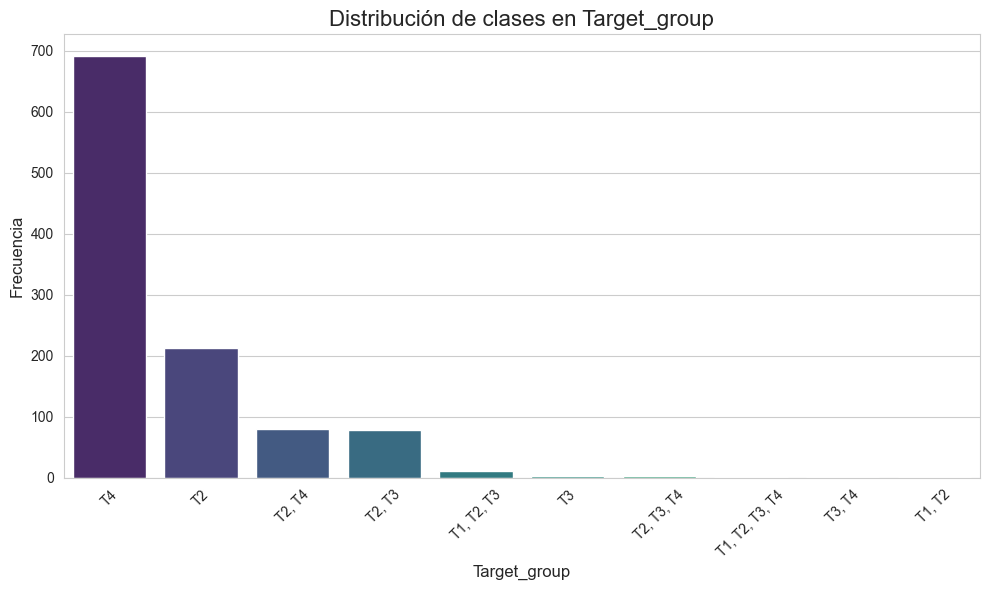

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=frecuencia_target_group.index, y=frecuencia_target_group.values, palette='viridis')

# Agregar etiquetas y título al gráfico
plt.title('Distribución de clases en Target_group', fontsize=16)
plt.xlabel('Target_group', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=45) # Rotar las etiquetas del eje X para mejor lectura
plt.tight_layout() # Ajustar el diseño para que todo se vea bien

# Mostrar el gráfico
plt.show()

## 5. FINAL CON LABEL = T4


In [9]:
import pandas as pd
import os
import networkx as nx
import numpy as np

# --- Configuración de directorios y rutas de archivos ---
# Asegúrate de que estas rutas sean correctas para tu entorno
BASE_OUTPUT = os.path.join(os.path.dirname(os.getcwd()), "output")
TRIAL = os.path.join(BASE_OUTPUT, "Trial_2")
final_output_dir = os.path.join(TRIAL, "topological_metrics")
os.makedirs(final_output_dir, exist_ok=True)

# Archivos de entrada
Data = os.path.join(TRIAL, "topological_metrics", "T4_metrics.xlsx")

print("Rutas de archivos configuradas.")

# --- Lectura del archivo Excel ---
try:
    # Si el archivo solo tiene una hoja, no necesitas especificar sheet_name
    df = pd.read_excel(Data)
    print("Archivo leído exitosamente.")
    
    # Imprimir los nombres de las columnas
    print("\nColumnas del DataFrame:")
    print(df.columns)

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{Data}'.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Rutas de archivos configuradas.
Archivo leído exitosamente.

Columnas del DataFrame:
Index(['Nombre proteína', 'Target_group', 'Cluster_label',
       'intracluster connect', 'intercluster connect', 'Conectivity_Score',
       'Termino GO'],
      dtype='object')


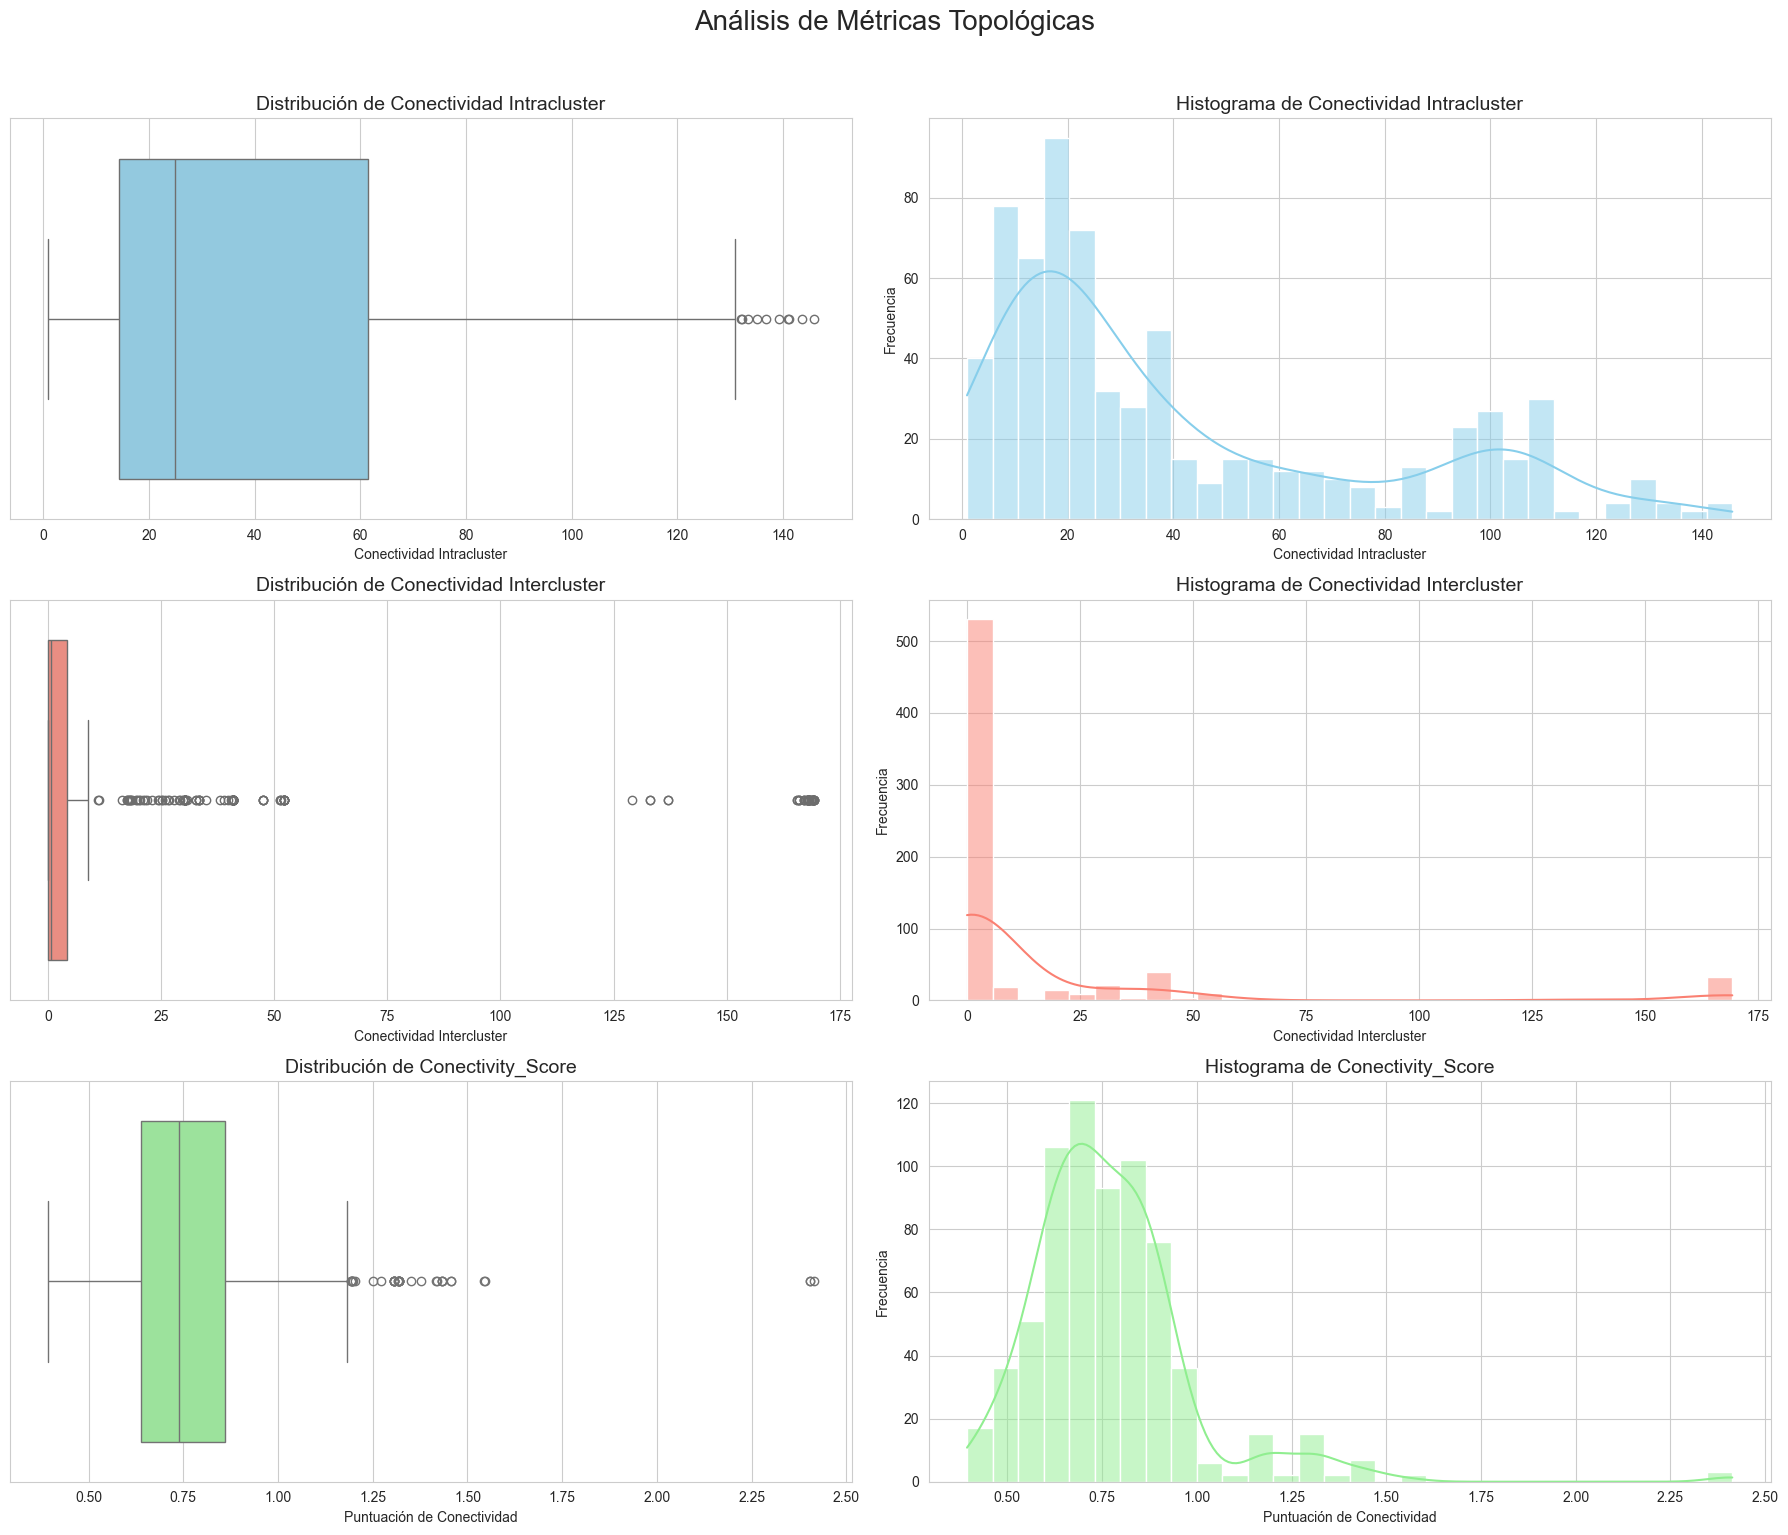

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
# --- Visualización de las métricas ---
# Configurar el estilo de seaborn
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Análisis de Métricas Topológicas', fontsize=20, y=1.02)

# --- Box Plots ---
# Box plot para 'intracluster connect'
sns.boxplot(x=df['intracluster connect'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Conectividad Intracluster', fontsize=14)
axes[0, 0].set_xlabel('Conectividad Intracluster')

# Box plot para 'intercluster connect'
sns.boxplot(x=df['intercluster connect'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribución de Conectividad Intercluster', fontsize=14)
axes[1, 0].set_xlabel('Conectividad Intercluster')

# Box plot para 'Conectivity_Score'
sns.boxplot(x=df['Conectivity_Score'], ax=axes[2, 0], color='lightgreen')
axes[2, 0].set_title('Distribución de Conectivity_Score', fontsize=14)
axes[2, 0].set_xlabel('Puntuación de Conectividad')

# --- Histogramas (KDE Plots) ---
# Histograma para 'intracluster connect'
sns.histplot(df['intracluster connect'], kde=True, ax=axes[0, 1], color='skyblue', bins=30)
axes[0, 1].set_title('Histograma de Conectividad Intracluster', fontsize=14)
axes[0, 1].set_xlabel('Conectividad Intracluster')
axes[0, 1].set_ylabel('Frecuencia')

# Histograma para 'intercluster connect'
sns.histplot(df['intercluster connect'], kde=True, ax=axes[1, 1], color='salmon', bins=30)
axes[1, 1].set_title('Histograma de Conectividad Intercluster', fontsize=14)
axes[1, 1].set_xlabel('Conectividad Intercluster')
axes[1, 1].set_ylabel('Frecuencia')

# Histograma para 'Conectivity_Score'
sns.histplot(df['Conectivity_Score'], kde=True, ax=axes[2, 1], color='lightgreen', bins=30)
axes[2, 1].set_title('Histograma de Conectivity_Score', fontsize=14)
axes[2, 1].set_xlabel('Puntuación de Conectividad')
axes[2, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [11]:
# --- Cálculo de percentiles ---
print("\n--- Percentiles de las Métricas ---")

# Calcular percentiles para 'intracluster connect'
intracluster_percentiles = df['intracluster connect'].quantile([0.25, 0.5, 0.75])
print("\nPercentiles de Conectividad Intracluster:")
print(intracluster_percentiles)

# Calcular percentiles para 'intercluster connect'
intercluster_percentiles = df['intercluster connect'].quantile([0.25, 0.5, 0.75])
print("\nPercentiles de Conectividad Intercluster:")
print(intercluster_percentiles)

# Calcular percentiles para 'Conectivity_Score'
connectivity_percentiles = df['Conectivity_Score'].quantile([0.25, 0.5, 0.75])
print("\nPercentiles de Conectivity_Score:")
print(connectivity_percentiles)


--- Percentiles de las Métricas ---

Percentiles de Conectividad Intracluster:
0.25    14.38950
0.50    24.91800
0.75    61.41525
Name: intracluster connect, dtype: float64

Percentiles de Conectividad Intercluster:
0.25    0.0000
0.50    0.5505
0.75    4.1035
Name: intercluster connect, dtype: float64

Percentiles de Conectivity_Score:
0.25    0.637584
0.50    0.739044
0.75    0.858947
Name: Conectivity_Score, dtype: float64


### Diagrama de Venn

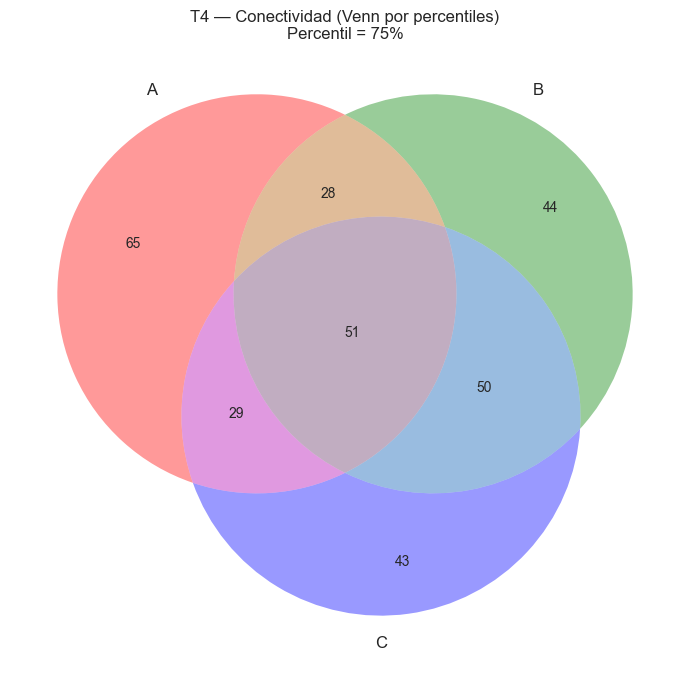


--- Leyenda del Diagrama ---
Círculo A: Proteínas con alta conectividad intraclúster
Círculo B: Proteínas con alta conectividad interclúster
Círculo C: Proteínas con alto Connectivity_Score

--- Umbrales (percentil) ---
intracluster_connect ≥ 61.4153
intercluster_connect ≥ 4.1035
connectivity_score ≥ 0.8589

--- Tamaño de conjuntos ---
A Intracluster alto: 173
B Intercluster alto: 173
C Score alto : 173

--- LISTA FINAL DE CANDIDATOS ---
Estas proteínas están en la intersección de A, B y C.
Son los hubs más importantes, con alta conectividad en todas las métricas.
- CALM1
- CALM2
- CPX-1009
- CPX-1112
- CPX-2196
- CPX-2205
- CPX-2212
- CPX-2272
- CPX-2280
- CPX-2292
- CPX-2295
- CPX-2296
- CPX-2297
- CPX-2298
- CPX-2307
- CPX-2309
- CPX-2310
- CPX-2317
- CPX-2318
- CPX-2320
- CPX-2323
- CPX-2330
- CPX-2341
- CPX-2555
- CPX-2557
- CPX-2569
- CPX-2570
- CPX-2571
- CPX-2627
- CPX-6186
- CPX-6189
- CPX-7111
- CPX-7519
- CPX-7522
- CPX-7523
- CPX-7524
- CPX-7525
- CPX-7526
- CPX-7527
- CPX

In [12]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# --- Normalizar nombres de columnas (espacios y acentos) ---
# Se mantiene el código de normalización de columnas
df = df.rename(columns={
    'Nombre proteína': 'protein_name',
    'Target_group': 'target_group',
    'Cluster_label': 'cluster_label',
    'intracluster connect': 'intracluster_connect',
    'intercluster connect': 'intercluster_connect',
    'Conectivity_Score': 'connectivity_score',
    'Termino GO': 'go_term'
}).copy()

# --- Asegurar tipos numéricos ---
# Se mantiene el código para asegurar tipos numéricos
for col in ['intracluster_connect', 'intercluster_connect', 'connectivity_score']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Función para armar Venn según percentil ---
def venn_connectivity_and_list_candidates(
    data: pd.DataFrame,
    p: float = 0.75,
    title: str = 'Diagrama de Venn: Conectividad (Top percentil)'
):
    # Umbrales por percentil
    thr_intra = data['intracluster_connect'].quantile(p)
    thr_inter = data['intercluster_connect'].quantile(p)
    thr_score = data['connectivity_score'].quantile(p)

    # Conjuntos
    set_A = set(data.loc[data['intracluster_connect'] >= thr_intra, 'protein_name'])
    set_B = set(data.loc[data['intercluster_connect'] >= thr_inter, 'protein_name'])
    set_C = set(data.loc[data['connectivity_score'] >= thr_score, 'protein_name'])

    # Figura
    plt.figure(figsize=(7, 7))
    v = venn3(
        subsets=(set_A, set_B, set_C),
        set_labels=('A', 'B', 'C') 
    )
    plt.title(f"{title}\nPercentil = {int(p*100)}%", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Leyenda para la interpretación
    print("\n--- Leyenda del Diagrama ---")
    print("Círculo A: Proteínas con alta conectividad intraclúster")
    print("Círculo B: Proteínas con alta conectividad interclúster")
    print("Círculo C: Proteínas con alto Connectivity_Score")

    # Reporte en consola
    print("\n--- Umbrales (percentil) ---")
    print(f"intracluster_connect ≥ {thr_intra:.4f}")
    print(f"intercluster_connect ≥ {thr_inter:.4f}")
    print(f"connectivity_score ≥ {thr_score:.4f}")

    print("\n--- Tamaño de conjuntos ---")
    print(f"A Intracluster alto: {len(set_A)}")
    print(f"B Intercluster alto: {len(set_B)}")
    print(f"C Score alto : {len(set_C)}")

    # Intersecciones
    all_ABC = set_A & set_B & set_C

    # --- LISTA FINAL DE CANDIDATOS ---
    print("\n--- LISTA FINAL DE CANDIDATOS ---")
    print("Estas proteínas están en la intersección de A, B y C.")
    print("Son los hubs más importantes, con alta conectividad en todas las métricas.")
    if len(all_ABC) > 0:
        for protein in sorted(list(all_ABC)):
            print(f"- {protein}")
    else:
        print("No se encontraron proteínas en la intersección triple.")
    
    # guardar all_ABC en un xlsx
    final_result_df = df[df['protein_name'].isin(all_ABC)].copy()
    output_path = os.path.join(final_output_dir, "all_ABC.xlsx")
    final_result_df.to_excel(output_path, index=False)
    print(f"\nResultados guardados en: {output_path}")

# === Ejecutar la función para obtener el diagrama y la lista ===
# Asegúrate de que 'df' contenga tus datos antes de ejecutar esta línea.
venn_connectivity_and_list_candidates(df, p=0.75, title='T4 — Conectividad (Venn por percentiles)')

* A (rojo): proteínas con alta conectividad intraclúster (bien conectadas dentro de su propio clúster).

* B (verde): proteínas con alta conectividad interclúster (conectadas hacia otros clústeres).

* C (azul): proteínas con alto Connectivity Score total (un resumen global de importancia).

---

* Sólo A (56): proteínas que son fuertes dentro de su clúster, pero no se destacan en conexiones externas ni en el score global → “hubs internos especializados”.

* Sólo B (29): proteínas que conectan con otros clústeres, pero sin ser fuertes internamente ni top en score global → “puentes débiles”.

* Sólo C (38): proteínas con alto score global, pero no sobresalientes específicamente en intra o inter → su relevancia viene de una combinación más balanceada.

---

* A ∩ B (27): proteínas que combinan conectividad intra + inter, aunque no alcanzan el top del score → buenos mediadores.

* A ∩ C (18): proteínas fuertes en intra y que además destacan en el score → hubs centrales dentro del clúster.

* B ∩ C (45): proteínas con alta inter + alto score → potenciales puentes críticos entre módulos.

* A ∩ B ∩ C (38): las proteínas más importantes de T4: destacan en todo (hubs globales que combinan cohesión interna, conexiones externas y score total).

¿Cuáles son los T4 más importantes?” → son los de la intersección triple (38 proteínas).

### Lista final de candidatos

### Proteina más conectada con otro cluster (intercluster)

¿Cuál es el T4 del GO más conectado con otros?” → puedes cruzar el conjunto B (altos en intercluster) con la columna go_term y ver qué términos GO están más representados ahí.

In [13]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'intercluster connect', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'intercluster connect' en orden descendente
    df_cluster = df_cluster.sort_values(by='intercluster_connect', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_1 = df_cluster.head(1)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_1_final = top_1[[
        'protein_name',
        'cluster_label',
        'intercluster_connect',
        'go_term'
    ]].copy()
    
    top_1_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'intercluster_connect': 'Intercluster_Connect_Score',
        'Termino GO': 'go_term'
    }, inplace=True)
    
    # 5. Agregar el DataFrame de las top 3 a la lista
    top_proteins_by_cluster.append(top_1_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de laa Proteína más Interconectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_1_intercluster_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de laa Proteína más Interconectadas por Clúster ---
   protein_name  Clúster  Intercluster_Connect_Score  \
0      CPX-1209       10                     169.223   
1         SUMO1       11                     128.989   
2      CPX-2453        5                      51.462   
3      CPX-1822        8                      39.789   
4          IRF1        9                      25.248   
5         RPE65        2                      17.320   
6           OTC        7                       7.624   
7      CPX-4945        1                       4.126   
8         EARS2        6                       4.096   
9         CYB5A        4                       3.174   
10         GJB2        3                       2.957   
11        FUCA1        0                       1.598   

            

### Proteina más conectada con otro cluster (intercluster)

In [14]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'intercluster connect', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'intercluster connect' en orden descendente
    df_cluster = df_cluster.sort_values(by='intracluster_connect', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_1 = df_cluster.head(1)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_1_final = top_1[[
        'protein_name',
        'cluster_label',
        'intracluster_connect',
        'go_term'
    ]].copy()
    
    top_1_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'intracluster_connect': 'Intracluster_Connect_Score',
        'Termino GO': 'go_term'
    }, inplace=True)

    # 5. Agregar el DataFrame de las top 1 a la lista
    top_proteins_by_cluster.append(top_1_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de laa Proteína más Intraconectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_1_intracluster_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de laa Proteína más Intraconectadas por Clúster ---
   protein_name  Clúster  Intracluster_Connect_Score  \
0      CPX-1202       10                      39.644   
1      CPX-7527       11                     109.095   
2      CPX-8641        5                     145.803   
3      CPX-1727        8                      31.434   
4           IL7        9                      28.994   
5           CRX        2                      37.587   
6      CPX-6233        7                      34.513   
7      CPX-6239        1                      27.508   
8         LARS2        6                      22.080   
9       SLC35A2        4                      32.701   
10         TMC1        3                      19.240   
11          GNS        0                      10.585   

            

### Proteína con mayor connectivy score

In [15]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'conectiviry score', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'conectiviy score' en orden descendente
    df_cluster = df_cluster.sort_values(by='connectivity_score', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_1 = df_cluster.head(1)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_1_final = top_1[[
        'protein_name',
        'cluster_label',
        'connectivity_score',
        'go_term'
    ]].copy()
    
    top_1_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'conectiviy_score': 'Connectivity_Score',
        'Termino GO': 'go_term'
    }, inplace=True)

    # 5. Agregar el DataFrame de las top 1 a la lista
    top_proteins_by_cluster.append(top_1_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de las Proteínas más Conectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_1_conectivity_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]



--- Tabla de las Proteínas más Conectadas por Clúster ---
   protein_name  Clúster  connectivity_score  \
0      CPX-1218       10            1.433302   
1      CPX-7601       11            1.132994   
2      CPX-2341        5            2.413216   
3      CPX-1766        8            0.791541   
4       CPX-833        9            0.945962   
5           NRL        2            0.774514   
6      CPX-7142        7            1.543442   
7      CPX-5675        1            1.547514   
8         SARS1        6            0.701168   
9       CYP26C1        4            0.996550   
10        CABP2        3            0.684636   
11        FUCA1        0            0.748784   

                                           go_term  
0                                     nBAF Complex  
1                                     PRC1 Complex  
2             Anterograde Trans-Synaptic Signaling  
3         Collagen-Containing Extracellular Matrix  
4   Type III Interferon-Mediated Signaling Pathway 

## Los dos primeros mejores

In [24]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'intercluster connect', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'intercluster connect' en orden descendente
    df_cluster = df_cluster.sort_values(by='intercluster_connect', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_2 = df_cluster.head(2)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_2_final = top_2[[
        'protein_name',
        'cluster_label',
        'intercluster_connect',
        'go_term'
    ]].copy()
    
    top_2_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'intercluster_connect': 'Intercluster_Connect_Score',
        'Termino GO': 'go_term'
    }, inplace=True)
    
    # 5. Agregar el DataFrame de las top 2 a la lista
    top_proteins_by_cluster.append(top_2_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de laa Proteína más Interconectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_2_intercluster_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de laa Proteína más Interconectadas por Clúster ---
   protein_name  Clúster  Intercluster_Connect_Score  \
0      CPX-1209       10                     169.223   
1      CPX-1216       10                     169.223   
2         SUMO1       11                     128.989   
3      CPX-2292       11                      52.128   
4      CPX-2453        5                      51.462   
5      CPX-2454        5                      51.333   
6      CPX-1822        8                      39.789   
7      CPX-1770        8                       4.599   
8          IRF1        9                      25.248   
9          TLR3        9                      24.485   
10        RPE65        2                      17.320   
11        CNGB1        2                      11.184   
12          O

In [28]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'intercluster connect', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'intercluster connect' en orden descendente
    df_cluster = df_cluster.sort_values(by='intracluster_connect', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_2 = df_cluster.head(2)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_2_final = top_2[[
        'protein_name',
        'cluster_label',
        'intracluster_connect',
        'go_term'
    ]].copy()
    
    top_2_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'intracluster_connect': 'Intracluster_Connect_Score',
        'Termino GO': 'go_term'
    }, inplace=True)

    # 5. Agregar el DataFrame de las top 1 a la lista
    top_proteins_by_cluster.append(top_2_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de laa Proteína más Intraconectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_2_intracluster_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de laa Proteína más Intraconectadas por Clúster ---
   protein_name  Clúster  Intracluster_Connect_Score  \
0      CPX-1202       10                      39.644   
1      CPX-1194       10                      39.644   
2      CPX-7527       11                     109.095   
3      CPX-7530       11                     109.095   
4      CPX-8641        5                     145.803   
5      CPX-8639        5                     143.664   
6      CPX-1727        8                      31.434   
7      CPX-1728        8                      31.434   
8           IL7        9                      28.994   
9      CPX-6050        9                      26.019   
10          CRX        2                      37.587   
11        RPE65        2                      37.172   
12     CPX-62

In [ ]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'conectiviry score', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'conectiviy score' en orden descendente
    df_cluster = df_cluster.sort_values(by='connectivity_score', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_2 = df_cluster.head(2)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_2_final = top_2[[
        'protein_name',
        'cluster_label',
        'connectivity_score',
        'go_term'
    ]].copy()
    
    top_2_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'conectiviy_score': 'Connectivity_Score',
        'Termino GO': 'go_term'
    }, inplace=True)

    # 5. Agregar el DataFrame de las top 1 a la lista
    top_proteins_by_cluster.append(top_2_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de las Proteínas más Conectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_2_conectivity_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de las Proteínas más Conectadas por Clúster ---
   protein_name  Clúster  connectivity_score  \
0      CPX-1218       10            1.433302   
1      CPX-4223       10            1.433276   
2      CPX-7601       11            1.132994   
3      CPX-2517       11            1.131875   
4      CPX-2341        5            2.413216   
5       CPX-998        5            2.404534   
6      CPX-1766        8            0.791541   
7       CPX-390        8            0.791541   
8       CPX-833        9            0.945962   
9          IRF1        9            0.903970   
10          NRL        2            0.774514   
11       GUCY2D        2            0.735108   
12     CPX-7142        7            1.543442   
13     CPX-6233        7            0.824477   
14     CPX-5675        1 

## TOP 5!!


In [16]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'intercluster connect', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'intercluster connect' en orden descendente
    df_cluster = df_cluster.sort_values(by='intercluster_connect', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_5 = df_cluster.head(5)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_5_final = top_5[[
        'protein_name',
        'cluster_label',
        'intercluster_connect',
        'go_term'
    ]].copy()
    
    top_5_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'intercluster_connect': 'Intercluster_Connect_Score',
        'Termino GO': 'go_term'
    }, inplace=True)
    
    # 5. Agregar el DataFrame de las top 2 a la lista
    top_proteins_by_cluster.append(top_5_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de laa Proteína más Interconectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_5_intercluster_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de laa Proteína más Interconectadas por Clúster ---
   protein_name  Clúster  Intercluster_Connect_Score  \
0      CPX-1209       10                     169.223   
1      CPX-1216       10                     169.223   
2      CPX-1219       10                     169.223   
3      CPX-1226       10                     169.223   
4      CPX-1202       10                     169.114   
5         SUMO1       11                     128.989   
6      CPX-2292       11                      52.128   
7      CPX-2295       11                      52.128   
8      CPX-2296       11                      52.128   
9      CPX-2297       11                      52.128   
10     CPX-2453        5                      51.462   
11     CPX-2454        5                      51.333   
12     CPX-24

In [17]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'intercluster connect', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'intercluster connect' en orden descendente
    df_cluster = df_cluster.sort_values(by='intracluster_connect', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_5 = df_cluster.head(5)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_5_final = top_5[[
        'protein_name',
        'cluster_label',
        'intracluster_connect',
        'go_term'
    ]].copy()
    
    top_5_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'intracluster_connect': 'Intracluster_Connect_Score',
        'Termino GO': 'go_term'
    }, inplace=True)

    # 5. Agregar el DataFrame de las top 1 a la lista
    top_proteins_by_cluster.append(top_5_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de laa Proteína más Intraconectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_5_intracluster_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de laa Proteína más Intraconectadas por Clúster ---
   protein_name  Clúster  Intracluster_Connect_Score  \
0      CPX-1202       10                      39.644   
1      CPX-1194       10                      39.644   
2      CPX-1225       10                      39.644   
3      CPX-1207       10                      39.644   
4      CPX-1203       10                      39.644   
5      CPX-7527       11                     109.095   
6      CPX-7530       11                     109.095   
7      CPX-7533       11                     109.095   
8      CPX-7524       11                     109.095   
9      CPX-7519       11                     108.916   
10     CPX-8641        5                     145.803   
11     CPX-8639        5                     143.664   
12     CPX-86

In [19]:
import pandas as pd
import os

# Assuming your DataFrame 'df' is already loaded with the correct column names
# (e.g., 'Nombre proteína', 'Cluster_label', 'conectiviry score', 'Termino GO')

# --- Preparar una lista para guardar los DataFrames de cada clúster ---
top_proteins_by_cluster = []

# --- Obtener una lista de todos los Cluster_label únicos ---
cluster_labels = df['cluster_label'].unique()

print("Procesando los siguientes clústeres:", sorted(cluster_labels))

# --- Recorrer cada clúster y obtener el top 1---
for cluster in cluster_labels:
    # 1. Filtrar el DataFrame por el clúster actual
    df_cluster = df[df['cluster_label'] == cluster].copy()

    # 2. Ordenar las proteínas del clúster por 'conectiviy score' en orden descendente
    df_cluster = df_cluster.sort_values(by='connectivity_score', ascending=False)

    # 3. Seleccionar la primera proteína y las columnas de interés
    top_5 = df_cluster.head(5)

    # 4. Seleccionar y renombrar las columnas para la tabla final
    top_5_final = top_5[[
        'protein_name',
        'cluster_label',
        'connectivity_score',
        'go_term'
    ]].copy()
    
    top_5_final.rename(columns={
        'Nombre proteína': 'Proteína',
        'cluster_label': 'Clúster',
        'conectiviy_score': 'Connectivity_Score',
        'Termino GO': 'go_term'
    }, inplace=True)

    # 5. Agregar el DataFrame de las top 1 a la lista
    top_proteins_by_cluster.append(top_5_final)

# --- Concatenar todos los DataFrames de los clústeres en uno solo ---
final_result_df = pd.concat(top_proteins_by_cluster, ignore_index=True)

# --- Imprimir la tabla final ---
print("\n--- Tabla de las Proteínas más Conectadas por Clúster ---")
print(final_result_df)

# --- (Opcional) Guardar el resultado en un nuevo archivo Excel ---
output_path = os.path.join(final_output_dir, "top_5_conectivity_proteins.xlsx")
final_result_df.to_excel(output_path, index=False)
print(f"\nResultados guardados en: {output_path}")

Procesando los siguientes clústeres: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- Tabla de las Proteínas más Conectadas por Clúster ---
   protein_name  Clúster  connectivity_score  \
0      CPX-1218       10            1.433302   
1      CPX-4223       10            1.433276   
2      CPX-1216       10            1.432838   
3      CPX-1217       10            1.418467   
4      CPX-1202       10            1.417851   
5      CPX-7601       11            1.132994   
6      CPX-2517       11            1.131875   
7      CPX-2317       11            1.038380   
8       CPX-104       11            1.032756   
9      CPX-2296       11            1.031685   
10     CPX-2341        5            2.413216   
11      CPX-998        5            2.404534   
12     CPX-1112        5            2.404534   
13     CPX-1009        5            1.180487   
14      SLC12A5        5 